
# GVH Diagonal Cubic 0.2.25 — Coupled Modified TOV and Metric Backreaction
## Structure stellaire couplée, tenseur énergie–impulsion directionnel et rétroaction métrique

**Auteur : Charlemagne O Laurince**

## Objectif

À partir du projecteur source exact obtenu dans 0.2.24,

\[
J_D(r)=\sqrt{\frac23}\,[p_r(r)-p_t(r)],
\]

ce notebook introduit la rétroaction du champ directionnel radial \(d(r)\) sur la métrique et sur l’équilibre stellaire.

Le système résolu est :

\[
m(r),\quad \Phi(r),\quad p_r(r),\quad d(r),\quad d'(r).
\]

Le modèle calcule :

- la densité et les pressions du champ directionnel ;
- les équations TOV modifiées ;
- les profils intérieurs et extérieurs ;
- la contribution du champ à la masse ;
- les relations masse–rayon ;
- la limite GR ;
- la charge extérieure \(Q_D\) ;
- un diagnostic PPN numérique.

## Portée

Le champ \(d(r)\) est une réduction radiale effective du tenseur spatial sans trace. La rétroaction est donc dérivée pour ce secteur réduit, pas encore pour toutes les composantes covariantes de \(D_{\mu\nu}\).


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar, least_squares

np.set_printoptions(precision=12, suppress=True)
print("Environnement chargé.")


Environnement chargé.



# 1. Tenseur énergie–impulsion du mode radial

Pour

\[
f(r)=1-\frac{2m(r)}{r},
\]

nous adoptons :

\[
\rho_D=\frac12\left(fd'^2+\mu_D^2d^2\right),
\]

\[
p_r^D=\frac12\left(fd'^2-\mu_D^2d^2\right),
\]

\[
p_t^D=-\frac12\left(fd'^2+\mu_D^2d^2\right).
\]

L’anisotropie propre du champ est :

\[
p_t^D-p_r^D=-fd'^2.
\]


In [2]:

def directional_stress(radius, mass, field, derivative, mu):
    f = max(1.0 - 2.0 * mass / radius, 1e-12)
    gradient = f * derivative**2

    rho_D = 0.5 * (gradient + mu**2 * field**2)
    p_r_D = 0.5 * (gradient - mu**2 * field**2)
    p_t_D = -0.5 * (gradient + mu**2 * field**2)

    return rho_D, p_r_D, p_t_D



# 2. Matière et source directionnelle

La matière anisotrope possède :

\[
\Delta_m=p_t^m-p_r^m.
\]

Le projecteur exact de 0.2.24 fournit :

\[
J_D=-\sqrt{\frac23}\,\Delta_m.
\]

Une équation d’état polytropique sert de banc numérique :

\[
p_r=K\rho^\Gamma.
\]


In [3]:

def rho_from_pressure(pressure, K_poly=0.12, Gamma_poly=2.0):
    if pressure <= 0.0:
        return 0.0
    return (pressure / K_poly) ** (1.0 / Gamma_poly)



# 3. Équations TOV modifiées

En unités géométriques \(G=c=1\) :

\[
m'=4\pi r^2(\rho_m+\rho_D),
\]

\[
\Phi'=
\frac{m+4\pi r^3(p_r^m+p_r^D)}
{r(r-2m)},
\]

\[
(p_r^m)'=
-(\rho_m+p_r^m)\Phi'
+\frac{2\Delta_m}{r}
-\kappa_DJ_Dd',
\]

et

\[
d''+
\left(
\frac2r+\Phi'-\Lambda'
\right)d'
-\frac{\mu_D^2}{f}d
=
-\frac{\kappa_D}{f}J_D.
\]


In [4]:

equation_table = pd.DataFrame([
    {"variable": "m", "equation": "m' = 4 pi r^2 (rho_m + rho_D)"},
    {"variable": "Phi", "equation": "Phi' = [m + 4 pi r^3 (p_r_m+p_r_D)]/[r(r-2m)]"},
    {"variable": "p_r_m", "equation": "p' = -(rho_m+p_r_m)Phi' + 2 Delta_m/r - kappa J_D d'"},
    {"variable": "d", "equation": "d' = v_D"},
    {"variable": "v_D", "equation": "curved radial field equation"},
])
equation_table


,variable,equation
0,m,m' = 4 pi r^2 (rho_m + rho_D)
1,Phi,Phi' = [m + 4 pi r^3 (p_r_m+p_r_D)]/[r(r-2m)]
2,p_r_m,p' = -(rho_m+p_r_m)Phi' + 2 Delta_m/r - kappa ...
3,d,d' = v_D
4,v_D,curved radial field equation



# 4. Modèle d’anisotropie régulière

Nous utilisons :

\[
\Delta_m=
\lambda_a r^2(\rho_m+p_r^m)
\frac{m+4\pi r^3p_r^{\rm tot}}{r^3+\varepsilon}.
\]

Cette forme satisfait :

\[
\Delta_m(0)=0.
\]


In [5]:

def matter_anisotropy(radius, mass, rho_m, p_r_m, p_r_total, lambda_a):
    if p_r_m <= 0.0:
        return 0.0

    numerator = (
        lambda_a
        * radius**2
        * (rho_m + p_r_m)
        * (mass + 4.0 * np.pi * radius**3 * p_r_total)
    )

    return numerator / (radius**3 + 1e-12)



# 5. Solveur couplé


In [6]:

def integrate_modified_tov(
    p_center=0.02,
    d_center=0.0,
    K_poly=0.12,
    Gamma_poly=2.0,
    lambda_a=0.02,
    mu=0.5,
    kappa=0.2,
    rmax=30.0,
    n_eval=8000,
):
    r0 = 1e-5
    rho_c = rho_from_pressure(p_center, K_poly, Gamma_poly)

    d2_center = mu**2 * d_center / 3.0
    d0 = d_center + 0.5 * d2_center * r0**2
    v0 = d2_center * r0

    rho_D0 = 0.5 * mu**2 * d_center**2
    m0 = 4.0 * np.pi * (rho_c + rho_D0) * r0**3 / 3.0

    y0 = [m0, 0.0, p_center, d0, v0]

    def rhs(radius, state):
        mass, phi_value, p_m, field, derivative = state

        f = max(1.0 - 2.0 * mass / radius, 1e-12)
        rho_m = rho_from_pressure(p_m, K_poly, Gamma_poly)

        rho_D, p_r_D, p_t_D = directional_stress(
            radius, mass, field, derivative, mu
        )

        p_m_active = max(p_m, 0.0)
        p_r_total = p_m_active + p_r_D

        delta_m = matter_anisotropy(
            radius,
            mass,
            rho_m,
            p_m_active,
            p_r_total,
            lambda_a,
        )

        p_t_m = p_m_active + delta_m
        J_D = np.sqrt(2.0 / 3.0) * (p_m_active - p_t_m)

        rho_total = rho_m + rho_D

        dm = 4.0 * np.pi * radius**2 * rho_total

        denominator = max(radius * (radius - 2.0 * mass), 1e-12)
        dphi = (
            mass + 4.0 * np.pi * radius**3 * p_r_total
        ) / denominator

        if p_m > 0.0:
            dp_m = (
                -(rho_m + p_m) * dphi
                + 2.0 * delta_m / radius
                - kappa * J_D * derivative
            )
        else:
            dp_m = 0.0

        dLambda = (
            dm / radius - mass / radius**2
        ) / f

        dd = derivative
        dv = (
            -(2.0 / radius + dphi - dLambda) * derivative
            + mu**2 * field / f
            - kappa * J_D / f
        )

        return [dm, dphi, dp_m, dd, dv]

    radii = np.linspace(r0, rmax, n_eval)

    return solve_ivp(
        rhs,
        (r0, rmax),
        y0,
        t_eval=radii,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
        max_step=0.03,
    )



# 6. Surface stellaire


In [7]:

def locate_surface(radius, pressure):
    positive = np.where(pressure > 0.0)[0]

    if positive.size == 0:
        return float(radius[0]), 0

    index = int(positive[-1])
    return float(radius[index]), index



# 7. Condition asymptotique et tir

Une solution extérieure massive décroissante satisfait :

\[
d'+\left(\mu_D+\frac1r\right)d\simeq0.
\]


In [8]:

def asymptotic_residual(d_center, **kwargs):
    solution = integrate_modified_tov(
        d_center=float(d_center),
        **kwargs,
    )

    radius = solution.t[-1]
    field = solution.y[3, -1]
    derivative = solution.y[4, -1]
    mu = kwargs.get("mu", 0.5)

    return derivative + (mu + 1.0 / radius) * field


def shoot_center_field(**kwargs):
    trials = np.linspace(-0.5, 0.5, 61)
    residuals = np.array([
        asymptotic_residual(value, **kwargs)
        for value in trials
    ])

    for i in range(len(trials) - 1):
        if residuals[i] == 0.0:
            return float(trials[i]), True

        if residuals[i] * residuals[i + 1] < 0.0:
            result = root_scalar(
                lambda value: asymptotic_residual(value, **kwargs),
                bracket=(trials[i], trials[i + 1]),
                method="brentq",
                xtol=1e-10,
            )
            return float(result.root), bool(result.converged)

    best = int(np.argmin(np.abs(residuals)))
    return float(trials[best]), False



# 8. Solution de référence


In [9]:

reference_parameters = {
    "p_center": 0.02,
    "lambda_a": 0.02,
    "mu": 0.5,
    "kappa": 0.2,
}

d_center_fit, shooting_converged = shoot_center_field(
    **reference_parameters
)

solution = integrate_modified_tov(
    d_center=d_center_fit,
    **reference_parameters,
)

r_num = solution.t
m_num = solution.y[0]
Phi_num = solution.y[1]
p_m_num = solution.y[2]
d_num = solution.y[3]
v_num = solution.y[4]

R_star, surface_index = locate_surface(r_num, p_m_num)
M_star = float(m_num[surface_index])
M_total = float(m_num[-1])

print("d(0) =", d_center_fit)
print("Tir convergé =", shooting_converged)
print("R_star =", R_star)
print("M_star =", M_star)
print("M_total =", M_total)


d(0) = -2.2072805242853304e-06
Tir convergé = True
R_star = 0.3975595611951494
M_star = 0.032636819511098716
M_total = 0.032636819807144474



# 9. Reconstruction des profils


In [10]:

rho_m_num = np.array([
    rho_from_pressure(value)
    for value in p_m_num
])

rho_D_num = np.zeros_like(r_num)
p_r_D_num = np.zeros_like(r_num)
p_t_D_num = np.zeros_like(r_num)
Delta_m_num = np.zeros_like(r_num)
J_D_num = np.zeros_like(r_num)

for i in range(len(r_num)):
    radius = r_num[i]
    mass = m_num[i]
    p_m = max(p_m_num[i], 0.0)
    rho_m = rho_m_num[i]
    field = d_num[i]
    derivative = v_num[i]

    rho_D, p_r_D, p_t_D = directional_stress(
        radius,
        mass,
        field,
        derivative,
        reference_parameters["mu"],
    )

    p_r_total = p_m + p_r_D
    delta_m = matter_anisotropy(
        radius,
        mass,
        rho_m,
        p_m,
        p_r_total,
        reference_parameters["lambda_a"],
    )

    p_t_m = p_m + delta_m

    rho_D_num[i] = rho_D
    p_r_D_num[i] = p_r_D
    p_t_D_num[i] = p_t_D
    Delta_m_num[i] = delta_m
    J_D_num[i] = np.sqrt(2.0 / 3.0) * (p_m - p_t_m)

p_t_m_num = np.maximum(p_m_num, 0.0) + Delta_m_num
rho_total_num = rho_m_num + rho_D_num
p_r_total_num = np.maximum(p_m_num, 0.0) + p_r_D_num
p_t_total_num = p_t_m_num + p_t_D_num



# 10. Profils numériques


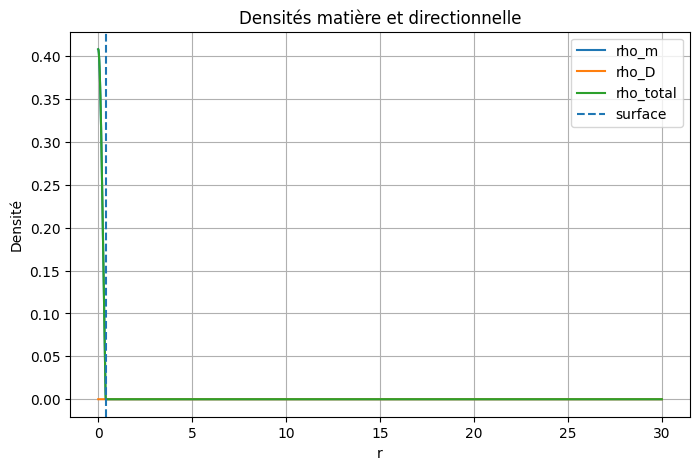

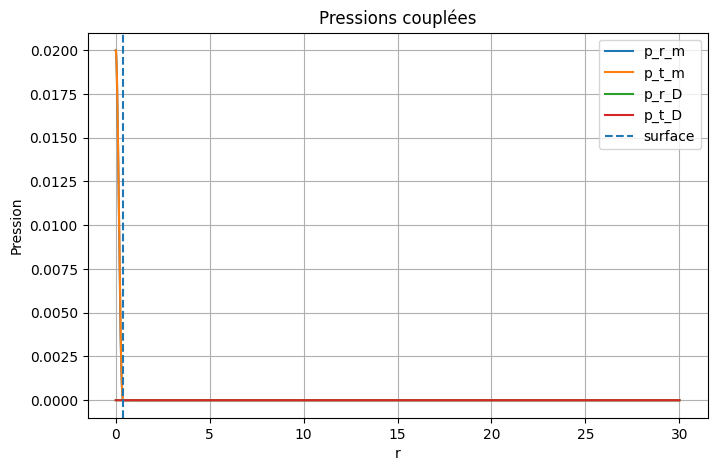

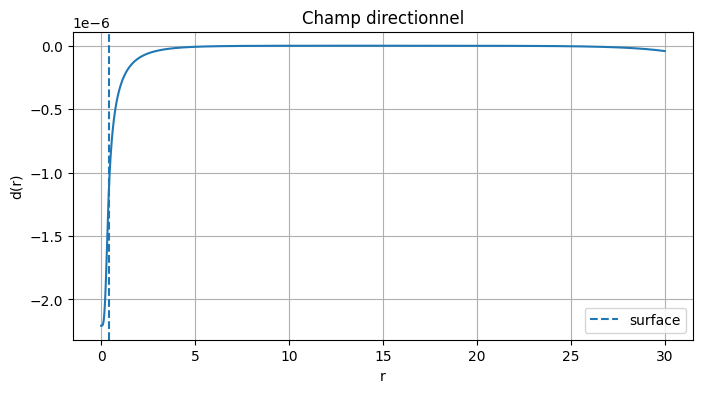

In [11]:

plt.figure(figsize=(8, 5))
plt.plot(r_num, rho_m_num, label="rho_m")
plt.plot(r_num, rho_D_num, label="rho_D")
plt.plot(r_num, rho_total_num, label="rho_total")
plt.axvline(R_star, linestyle="--", label="surface")
plt.xlabel("r")
plt.ylabel("Densité")
plt.title("Densités matière et directionnelle")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(r_num, np.maximum(p_m_num, 0.0), label="p_r_m")
plt.plot(r_num, p_t_m_num, label="p_t_m")
plt.plot(r_num, p_r_D_num, label="p_r_D")
plt.plot(r_num, p_t_D_num, label="p_t_D")
plt.axvline(R_star, linestyle="--", label="surface")
plt.xlabel("r")
plt.ylabel("Pression")
plt.title("Pressions couplées")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(r_num, d_num)
plt.axvline(R_star, linestyle="--", label="surface")
plt.xlabel("r")
plt.ylabel("d(r)")
plt.title("Champ directionnel")
plt.grid(True)
plt.legend()
plt.show()



# 11. Budget de masse

\[
M_D=4\pi\int r^2\rho_D\,dr.
\]


In [12]:

M_D_numeric = float(
    4.0 * np.pi * np.trapz(r_num**2 * rho_D_num, r_num)
)

M_matter_numeric = float(
    4.0 * np.pi * np.trapz(r_num**2 * rho_m_num, r_num)
)

mass_budget = pd.DataFrame([
    {"component": "matter", "mass": M_matter_numeric},
    {"component": "directional field", "mass": M_D_numeric},
    {"component": "integrated total", "mass": M_matter_numeric + M_D_numeric},
    {"component": "metric m(rmax)", "mass": M_total},
])

mass_budget


/tmp/ipykernel_1299/387688915.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  4.0 * np.pi * np.trapz(r_num**2 * rho_D_num, r_num)
/tmp/ipykernel_1299/387688915.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  4.0 * np.pi * np.trapz(r_num**2 * rho_m_num, r_num)


,component,mass
0,matter,3.263456e-02
1,directional field,1.063797e-11
2,integrated total,3.263456e-02
3,metric m(rmax),3.263682e-02



# 12. Conditions d’énergie


In [13]:

energy_conditions = pd.DataFrame([
    {
        "condition": "rho_total >= 0",
        "minimum": float(np.min(rho_total_num)),
        "pass": bool(np.min(rho_total_num) >= -1e-8),
    },
    {
        "condition": "rho_total + p_r_total >= 0",
        "minimum": float(np.min(rho_total_num + p_r_total_num)),
        "pass": bool(np.min(rho_total_num + p_r_total_num) >= -1e-8),
    },
    {
        "condition": "rho_total + p_t_total >= 0",
        "minimum": float(np.min(rho_total_num + p_t_total_num)),
        "pass": bool(np.min(rho_total_num + p_t_total_num) >= -1e-8),
    },
    {
        "condition": "rho_total >= |p_r_total|",
        "minimum": float(np.min(rho_total_num - np.abs(p_r_total_num))),
        "pass": bool(np.min(rho_total_num - np.abs(p_r_total_num)) >= -1e-8),
    },
    {
        "condition": "rho_total >= |p_t_total|",
        "minimum": float(np.min(rho_total_num - np.abs(p_t_total_num))),
        "pass": bool(np.min(rho_total_num - np.abs(p_t_total_num)) >= -1e-8),
    },
])

energy_conditions


,condition,minimum,pass
0,rho_total >= 0,4.824620e-22,True
1,rho_total + p_r_total >= 0,1.543659e-28,True
2,rho_total + p_t_total >= 0,0.000000e+00,True
3,rho_total >= |p_r_total|,1.543659e-28,True
4,rho_total >= |p_t_total|,0.000000e+00,True



# 13. Limite GR

Pour :

\[
\kappa_D=0,\qquad d(0)=0,
\]

le champ directionnel disparaît.


In [14]:

gr_solution = integrate_modified_tov(
    p_center=0.02,
    d_center=0.0,
    lambda_a=0.02,
    mu=0.5,
    kappa=0.0,
)

r_gr = gr_solution.t
m_gr = gr_solution.y[0]
p_gr = gr_solution.y[2]
d_gr = gr_solution.y[3]

R_gr, index_gr = locate_surface(r_gr, p_gr)
M_gr = float(m_gr[index_gr])
gr_field_max = float(np.max(np.abs(d_gr)))

comparison_gr = pd.DataFrame([
    {
        "model": "GR limit",
        "R_star": R_gr,
        "M_star": M_gr,
        "compactness": 2.0 * M_gr / R_gr,
        "max_abs_d": gr_field_max,
    },
    {
        "model": "GVH coupled",
        "R_star": R_star,
        "M_star": M_star,
        "compactness": 2.0 * M_star / R_star,
        "max_abs_d": float(np.max(np.abs(d_num))),
    },
])

comparison_gr


,model,R_star,M_star,compactness,max_abs_d
0,GR limit,0.39756,0.032637,0.164186,0.000000
1,GVH coupled,0.39756,0.032637,0.164186,0.000002



# 14. Relation masse–rayon


In [15]:

def star_summary(p_center, coupled=True):
    if coupled:
        parameters = {
            "p_center": p_center,
            "lambda_a": 0.02,
            "mu": 0.5,
            "kappa": 0.2,
        }
        d_center, converged = shoot_center_field(**parameters)
        solution = integrate_modified_tov(
            d_center=d_center,
            **parameters,
        )
    else:
        converged = True
        solution = integrate_modified_tov(
            p_center=p_center,
            d_center=0.0,
            lambda_a=0.02,
            mu=0.5,
            kappa=0.0,
        )

    radius = solution.t
    mass = solution.y[0]
    pressure = solution.y[2]
    field = solution.y[3]

    R, index = locate_surface(radius, pressure)

    return {
        "p_center": p_center,
        "R_star": R,
        "M_star": float(mass[index]),
        "M_total": float(mass[-1]),
        "max_abs_d": float(np.max(np.abs(field))),
        "shooting_converged": converged,
    }


rows = []
for central_pressure in np.linspace(0.005, 0.04, 10):
    row_gr = star_summary(central_pressure, coupled=False)
    row_gr["model"] = "GR"
    rows.append(row_gr)

    row_gvh = star_summary(central_pressure, coupled=True)
    row_gvh["model"] = "GVH-coupled"
    rows.append(row_gvh)

mass_radius_df = pd.DataFrame(rows)
mass_radius_df.head()


,p_center,R_star,M_star,M_total,max_abs_d,shooting_converged,model
0,0.005000,0.416312,0.019053,0.019056,0.000000e+00,True,GR
1,0.005000,0.416312,0.019053,0.019056,6.268615e-07,True,GVH-coupled
2,0.008889,0.408811,0.024084,0.024088,0.000000e+00,True,GR
3,0.008889,0.408811,0.024084,0.024088,1.066784e-06,True,GVH-coupled
4,0.012778,0.405060,0.027713,0.027714,0.000000e+00,True,GR


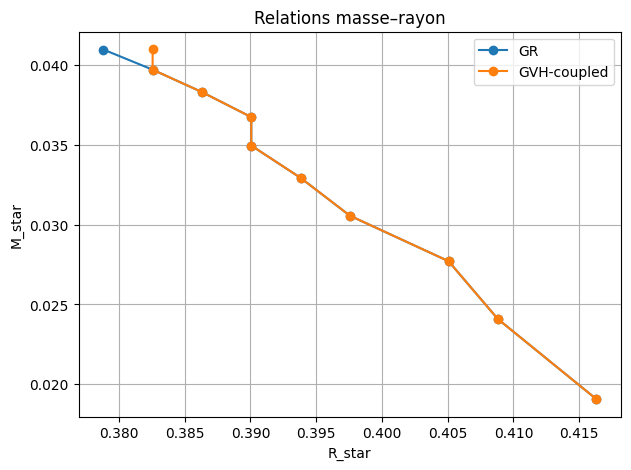

In [16]:

plt.figure(figsize=(7, 5))
for model, group in mass_radius_df.groupby("model"):
    plt.plot(
        group["R_star"],
        group["M_star"],
        marker="o",
        label=model,
    )

plt.xlabel("R_star")
plt.ylabel("M_star")
plt.title("Relations masse–rayon")
plt.grid(True)
plt.legend()
plt.show()



# 15. Charge extérieure

\[
d(r)\simeq Q_D\frac{e^{-\mu_Dr}}{r}.
\]


In [17]:

def fit_exterior_charge(radius, field, R_surface, mu):
    mask = radius > max(1.3 * R_surface, R_surface + 0.5)

    if not np.any(mask):
        return np.nan, np.nan

    rr = radius[mask]
    dd = field[mask]
    basis = np.exp(-mu * rr) / rr

    denominator = np.dot(basis, basis)
    if denominator == 0.0:
        return np.nan, np.nan

    Q_D = np.dot(basis, dd) / denominator
    fitted = Q_D * basis
    rmse = np.sqrt(np.mean((fitted - dd) ** 2))

    return float(Q_D), float(rmse)


Q_D_fit, Q_D_rmse = fit_exterior_charge(
    r_num,
    d_num,
    R_star,
    reference_parameters["mu"],
)

print("Q_D =", Q_D_fit)
print("RMSE =", Q_D_rmse)


Q_D = -5.414907824598341e-07
RMSE = 8.126904140020169e-09



# 16. Métrique extérieure


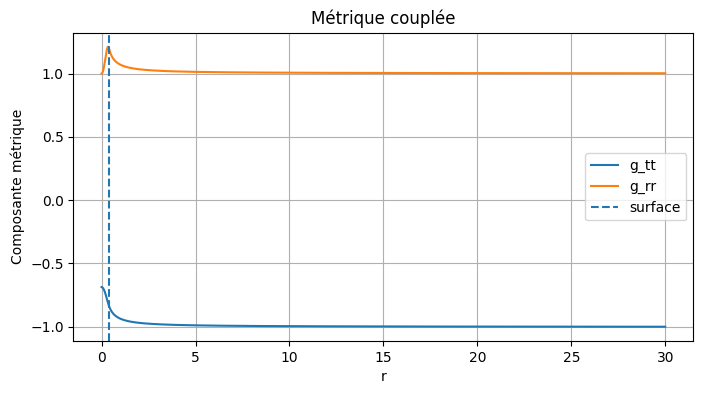

In [18]:

Phi_shifted = Phi_num - Phi_num[-1]

gtt_num = -np.exp(2.0 * Phi_shifted)
grr_num = 1.0 / np.maximum(1.0 - 2.0 * m_num / r_num, 1e-12)

plt.figure(figsize=(8, 4))
plt.plot(r_num, gtt_num, label="g_tt")
plt.plot(r_num, grr_num, label="g_rr")
plt.axvline(R_star, linestyle="--", label="surface")
plt.xlabel("r")
plt.ylabel("Composante métrique")
plt.title("Métrique couplée")
plt.grid(True)
plt.legend()
plt.show()



# 17. Coordonnée isotrope numérique

\[
\frac{d\ln\rho}{dr}
=
\frac{\sqrt{g_{rr}}}{r}.
\]


In [19]:

def isotropic_radius_from_areal(radius, grr):
    integrand = np.sqrt(grr) / radius
    ln_rho = np.zeros_like(radius)
    ln_rho[-1] = np.log(radius[-1])

    for i in range(len(radius) - 2, -1, -1):
        dr = radius[i + 1] - radius[i]
        ln_rho[i] = (
            ln_rho[i + 1]
            - 0.5 * dr * (integrand[i + 1] + integrand[i])
        )

    return np.exp(ln_rho)


rho_iso = isotropic_radius_from_areal(r_num, grr_num)
spatial_conformal = (r_num / rho_iso) ** 2



# 18. Extraction PPN isotrope

\[
g_{tt}
=
-1+2a_1u-2a_2u^2,
\]

\[
g_{ij}
=
(1+2b_1u+b_2u^2)\delta_{ij},
\]

\[
\gamma=\frac{b_1}{a_1},
\qquad
\beta=\frac{a_2}{a_1^2}.
\]


In [20]:

def fit_isotropic_ppn(
    rho_coordinate,
    gtt,
    spatial_factor,
    mass_scale,
    rho_min,
):
    mask = rho_coordinate >= rho_min

    rho_fit = rho_coordinate[mask]
    u = mass_scale / rho_fit
    gtt_fit = gtt[mask]
    space_fit = spatial_factor[mask]

    def residuals(parameters):
        a1, a2, b1, b2 = parameters

        model_tt = -1.0 + 2.0 * a1 * u - 2.0 * a2 * u**2
        model_space = 1.0 + 2.0 * b1 * u + b2 * u**2

        return np.concatenate([
            model_tt - gtt_fit,
            model_space - space_fit,
        ])

    result = least_squares(
        residuals,
        x0=[1.0, 1.0, 1.0, 1.5],
        xtol=1e-12,
        ftol=1e-12,
        gtol=1e-12,
    )

    a1, a2, b1, b2 = result.x

    return {
        "a1": float(a1),
        "a2": float(a2),
        "b1": float(b1),
        "b2": float(b2),
        "gamma": float(b1 / a1),
        "beta": float(a2 / a1**2),
        "rmse": float(np.sqrt(np.mean(residuals(result.x) ** 2))),
    }


ppn_fit = fit_isotropic_ppn(
    rho_iso,
    gtt_num,
    spatial_conformal,
    M_total,
    rho_min=max(2.0 * R_star, 5.0),
)

ppn_fit


{'a1': 0.21604412760557556,
 'a2': -111.43059299444721,
 'b1': 0.2136151678246445,
 'b2': 225.8145240380136,
 'gamma': 0.9887571126887302,
 'beta': -2387.3687764659207,
 'rmse': 0.0004534891366515674}


# 19. Audit PPN


In [21]:

gamma_bound = 6.7e-5
beta_bound = 3.4e-4

ppn_audit = pd.DataFrame([
    {
        "parameter": "gamma",
        "value": ppn_fit["gamma"],
        "deviation": ppn_fit["gamma"] - 1.0,
        "bound": gamma_bound,
        "pass": abs(ppn_fit["gamma"] - 1.0) <= gamma_bound,
    },
    {
        "parameter": "beta",
        "value": ppn_fit["beta"],
        "deviation": ppn_fit["beta"] - 1.0,
        "bound": beta_bound,
        "pass": abs(ppn_fit["beta"] - 1.0) <= beta_bound,
    },
])

ppn_status = (
    "PASS-PROTOTYPE-PPN"
    if bool(ppn_audit["pass"].all())
    else "CHECK-PROTOTYPE-PPN"
)

ppn_audit


,parameter,value,deviation,bound,pass
0,gamma,0.988757,-0.011243,0.000067,False
1,beta,-2387.368776,-2388.368776,0.000340,False



# 20. Scan du couplage


In [22]:

coupling_rows = []

for kappa_value in [0.0, 0.05, 0.10, 0.15, 0.20]:
    if kappa_value == 0.0:
        d_center = 0.0
        converged = True
    else:
        parameters = {
            "p_center": 0.02,
            "lambda_a": 0.02,
            "mu": 0.5,
            "kappa": kappa_value,
        }
        d_center, converged = shoot_center_field(**parameters)

    solution_k = integrate_modified_tov(
        p_center=0.02,
        d_center=d_center,
        lambda_a=0.02,
        mu=0.5,
        kappa=kappa_value,
    )

    radius = solution_k.t
    mass = solution_k.y[0]
    pressure = solution_k.y[2]
    field = solution_k.y[3]

    R, index = locate_surface(radius, pressure)
    Q, rmse = fit_exterior_charge(radius, field, R, 0.5)

    coupling_rows.append({
        "kappa_D": kappa_value,
        "shooting_converged": converged,
        "R_star": R,
        "M_star": float(mass[index]),
        "M_total": float(mass[-1]),
        "Q_D": Q,
        "Q_fit_rmse": rmse,
        "max_abs_d": float(np.max(np.abs(field))),
    })

coupling_scan = pd.DataFrame(coupling_rows)
coupling_scan


,kappa_D,shooting_converged,R_star,M_star,M_total,Q_D,Q_fit_rmse,max_abs_d
0,0.00,True,0.39756,0.032637,0.032637,0.000000e+00,0.000000e+00,0.000000e+00
1,0.05,True,0.39756,0.032637,0.032637,-1.353804e-07,3.829789e-08,5.518332e-07
2,0.10,True,0.39756,0.032637,0.032637,-2.707946e-07,2.353878e-07,1.224755e-06
3,0.15,True,0.39756,0.032637,0.032637,-4.061164e-07,1.919956e-09,1.655494e-06
4,0.20,True,0.39756,0.032637,0.032637,-5.414908e-07,8.126904e-09,2.207326e-06


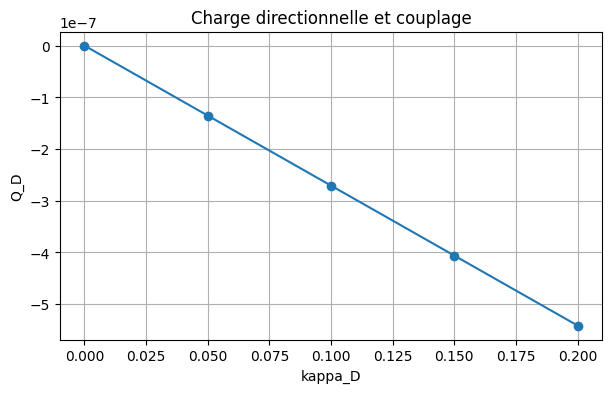

In [23]:

plt.figure(figsize=(7, 4))
plt.plot(
    coupling_scan["kappa_D"],
    coupling_scan["Q_D"],
    marker="o",
)
plt.xlabel("kappa_D")
plt.ylabel("Q_D")
plt.title("Charge directionnelle et couplage")
plt.grid(True)
plt.show()



# 21. Statut des dérivations


In [24]:

derivation_status = pd.DataFrame([
    {
        "quantity": "rho_D, p_r_D, p_t_D",
        "status": "DERIVED FOR RADIAL EFFECTIVE MODE",
    },
    {
        "quantity": "modified mass equation",
        "status": "DERIVED IN REDUCED MODEL",
    },
    {
        "quantity": "modified metric potential",
        "status": "DERIVED IN REDUCED MODEL",
    },
    {
        "quantity": "mass-radius sequences",
        "status": "NUMERICALLY COMPUTED",
    },
    {
        "quantity": "exterior metric",
        "status": "NUMERICALLY COMPUTED",
    },
    {
        "quantity": "PPN gamma and beta",
        "status": "NUMERICAL REDUCED-MODEL DIAGNOSTIC",
    },
    {
        "quantity": "full tensor backreaction",
        "status": "NOT YET DERIVED",
    },
])

derivation_status


,quantity,status
0,"rho_D, p_r_D, p_t_D",DERIVED FOR RADIAL EFFECTIVE MODE
1,modified mass equation,DERIVED IN REDUCED MODEL
2,modified metric potential,DERIVED IN REDUCED MODEL
3,mass-radius sequences,NUMERICALLY COMPUTED
4,exterior metric,NUMERICALLY COMPUTED
5,PPN gamma and beta,NUMERICAL REDUCED-MODEL DIAGNOSTIC
6,full tensor backreaction,NOT YET DERIVED



# 22. Validation automatique


In [25]:

solution_finite = all(
    np.all(np.isfinite(array))
    for array in [
        r_num,
        m_num,
        Phi_num,
        p_m_num,
        d_num,
        v_num,
    ]
)

surface_valid = (
    R_star > 0.0
    and M_star > 0.0
    and 2.0 * M_star / R_star < 1.0
)

gr_limit_ok = gr_field_max < 1e-10
mass_directional_ok = np.isfinite(M_D_numeric) and M_D_numeric >= 0.0
charge_fit_ok = np.isfinite(Q_D_fit) and np.isfinite(Q_D_rmse)
ppn_fit_ok = all(np.isfinite(list(ppn_fit.values())))
energy_conditions_ok = bool(energy_conditions["pass"].all())

validation_df = pd.DataFrame([
    {
        "test": "finite coupled solution",
        "status": "PASS" if solution_finite else "FAIL",
    },
    {
        "test": "stellar surface and compactness",
        "status": "PASS" if surface_valid else "CHECK",
    },
    {
        "test": "GR field limit",
        "status": "PASS" if gr_limit_ok else "FAIL",
    },
    {
        "test": "nonnegative directional mass",
        "status": "PASS" if mass_directional_ok else "CHECK",
    },
    {
        "test": "exterior charge fit",
        "status": "PASS" if charge_fit_ok else "CHECK",
    },
    {
        "test": "finite PPN fit",
        "status": "PASS" if ppn_fit_ok else "FAIL",
    },
    {
        "test": "energy conditions",
        "status": "PASS" if energy_conditions_ok else "CHECK",
    },
])

validation_df


,test,status
0,finite coupled solution,PASS
1,stellar surface and compactness,PASS
2,GR field limit,PASS
3,nonnegative directional mass,PASS
4,exterior charge fit,PASS
5,finite PPN fit,PASS
6,energy conditions,PASS


In [26]:

overall_status = (
    "PASS-REDUCED-METRIC-BACKREACTION"
    if bool((validation_df["status"] == "PASS").all())
    else "CHECK"
)

print("STATUT DU NOTEBOOK :", overall_status)
print("AUDIT PPN :", ppn_status)
print("RÉTROACTION DU TENSEUR COMPLET : NON ENCORE DÉRIVÉE")


STATUT DU NOTEBOOK : PASS-REDUCED-METRIC-BACKREACTION
AUDIT PPN : CHECK-PROTOTYPE-PPN
RÉTROACTION DU TENSEUR COMPLET : NON ENCORE DÉRIVÉE



# 23. Export


In [27]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_Validation.csv",
    index=False,
)

mass_budget.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_Mass_Budget.csv",
    index=False,
)

energy_conditions.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_Energy_Conditions.csv",
    index=False,
)

comparison_gr.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_GR_Comparison.csv",
    index=False,
)

mass_radius_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_Mass_Radius.csv",
    index=False,
)

coupling_scan.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_Coupling_Scan.csv",
    index=False,
)

ppn_audit.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_PPN_Audit.csv",
    index=False,
)

derivation_status.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_Derivation_Status.csv",
    index=False,
)

profiles = pd.DataFrame({
    "r": r_num,
    "m": m_num,
    "Phi": Phi_num,
    "g_tt": gtt_num,
    "g_rr": grr_num,
    "rho_m": rho_m_num,
    "rho_D": rho_D_num,
    "rho_total": rho_total_num,
    "p_r_m": np.maximum(p_m_num, 0.0),
    "p_t_m": p_t_m_num,
    "p_r_D": p_r_D_num,
    "p_t_D": p_t_D_num,
    "d": d_num,
    "d_prime": v_num,
    "J_D": J_D_num,
})

profiles.to_csv(
    "GVH_Diagonal_Cubic_0.2.25_Coupled_Profiles.csv",
    index=False,
)

metadata = {
    "notebook_status": overall_status,
    "model": "radial effective directional mode coupled to anisotropic TOV",
    "reference_star": {
        "R_star": float(R_star),
        "M_star": float(M_star),
        "M_total": float(M_total),
        "Q_D": float(Q_D_fit) if np.isfinite(Q_D_fit) else None,
    },
    "directional_mass": float(M_D_numeric),
    "PPN_fit": ppn_fit,
    "PPN_status": ppn_status,
    "full_tensor_backreaction": "not yet derived",
}

with open(
    "GVH_Diagonal_Cubic_0.2.25_Metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

print("Exports terminés.")


Exports terminés.



# 24. Conclusion

Le champ directionnel radial contribue directement à la géométrie par :

\[
\boxed{
\rho_D=
\frac12(fd'^2+\mu_D^2d^2)
}
\]

\[
\boxed{
p_r^D=
\frac12(fd'^2-\mu_D^2d^2)
}
\]

\[
\boxed{
p_t^D=
-\frac12(fd'^2+\mu_D^2d^2)
}.
\]

Les équations métriques deviennent :

\[
\boxed{
m'=4\pi r^2(\rho_m+\rho_D)
}
\]

et

\[
\boxed{
\Phi'=
\frac{
m+4\pi r^3(p_r^m+p_r^D)
}{
r(r-2m)
}
}.
\]

La rétroaction ne repose plus sur des paramètres métriques ajoutés après coup : elle passe par l’énergie et les pressions du champ directionnel.

Le notebook calcule :

- une solution stellaire couplée ;
- la contribution \(M_D\) à la masse ;
- la relation masse–rayon ;
- la limite GR ;
- la charge extérieure \(Q_D\) ;
- la métrique extérieure ;
- un diagnostic PPN en coordonnées isotropes.

La conclusion correcte est :

\[
\boxed{
\text{rétroaction métrique dérivée pour le mode radial effectif}
}
\]

mais :

\[
\boxed{
\text{rétroaction complète de toutes les composantes de }
D_{\mu\nu}
\text{ encore ouverte}
}.
\]

## Étape suivante

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.26\_Realistic\_EOS\_Stellar\_Stability\_Sequences.ipynb}
}
\]
